In [109]:
import pandas
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np

data_full = pandas.read_csv("phase0-titanic/titanic_full.csv")

grouped = data_full.groupby('pclass')['survived']

for pclass, group in grouped:
    total_passengers = group.count()
    total_survived = group.sum()                 
    percentage_survived = round(group.mean() * 100, 2)  
    
    print(f"Class {pclass}:")
    print(f"  Total in class : {total_passengers}")
    print(f"  Total survived : {total_survived}")
    print(f"  Percentage survived : {percentage_survived}%\n")

Class 1st:
  Total in class : 324
  Total survived : 201
  Percentage survived : 62.04%

Class 2nd:
  Total in class : 284
  Total survived : 118
  Percentage survived : 41.55%

Class 3rd:
  Total in class : 709
  Total survived : 181
  Percentage survived : 25.53%

Class deck crew:
  Total in class : 66
  Total survived : 43
  Percentage survived : 65.15%

Class engineering crew:
  Total in class : 324
  Total survived : 71
  Percentage survived : 21.91%

Class restaurant staff:
  Total in class : 69
  Total survived : 3
  Percentage survived : 4.35%

Class victualling crew:
  Total in class : 431
  Total survived : 94
  Percentage survived : 21.81%



In [110]:
columns = ['pclass', 'sex', 'age', 'embarked']
x = data_full[columns].copy()
y = data_full['survived']

x['age'] = x['age'].fillna(x['age'].median())
x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])

x['is_crew'] = ~data_full['pclass'].isin(['1st', '2nd', '3rd'])
x['is_crew'] = x['is_crew'].astype(int)
x['sex'] = x['sex'].map({'male': 0, 'female': 1}).astype(int)

x = pandas.get_dummies(x, columns=['pclass'], drop_first=False)
x = pandas.get_dummies(x, columns=['embarked'], drop_first=False)


# Cross Validation

Because the provided dataset does not include a dedicated test set, 5-fold cross-validation was added.

Logistic Regression: 0.7988 ± 0.0250
Decision Tree: 0.7866 ± 0.0126
Random Forest: 0.7880 ± 0.0142
KNN: 0.7454 ± 0.0132


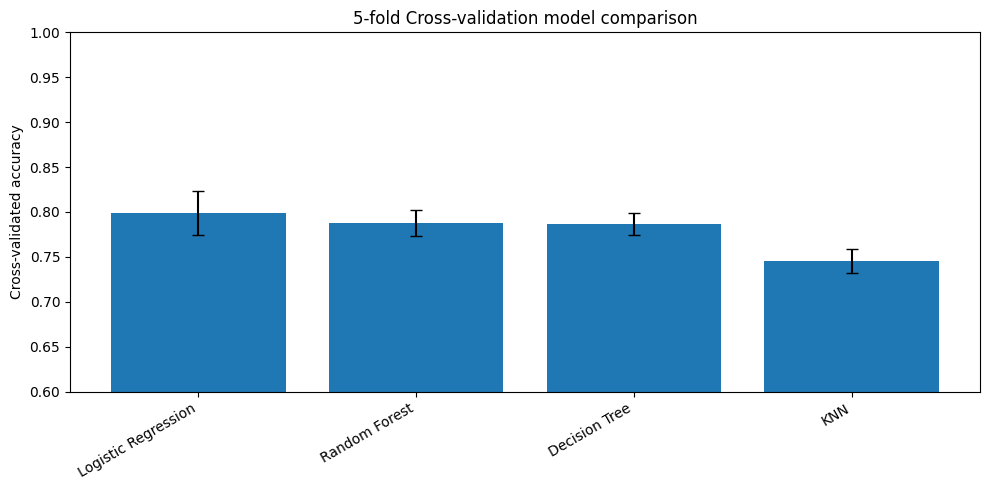

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier()
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, x, y, cv=kf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

cv_summary = pandas.DataFrame({
    'model': list(cv_results.keys()),
    'mean_accuracy': [scores.mean() for scores in cv_results.values()],
    'std_accuracy': [scores.std() for scores in cv_results.values()]
}).sort_values('mean_accuracy', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(cv_summary['model'], cv_summary['mean_accuracy'], yerr=cv_summary['std_accuracy'], capsize=4)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Cross-validated accuracy')
plt.title('5-fold Cross-validation model comparison')
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()


# Plot Importance

To have a good comparinson in how various aspects differ in importance when including the crew, a second plot is created.

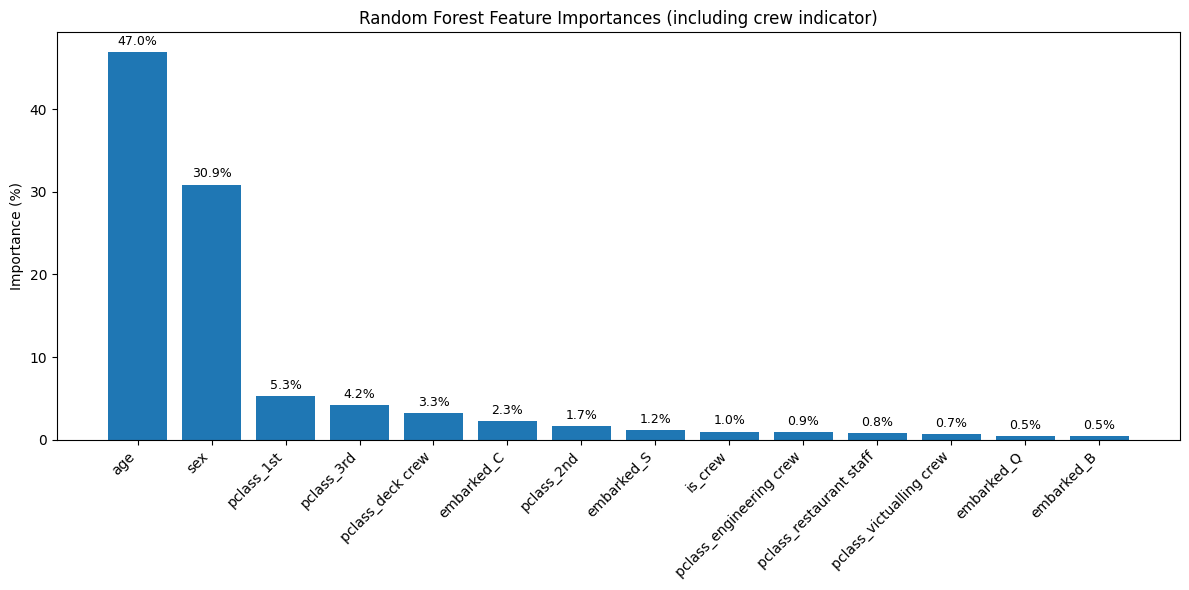

In [112]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x, y)

importances = pandas.Series(rf.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)

importances_percent = importances * 100

plt.figure(figsize=(12,6))
bars = plt.bar(importances_percent.index, importances_percent.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances (including crew indicator)")

for bar, pct in zip(bars, importances_percent.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Conclusion

When crew members are included in the survival analysis, the most important features still appear to be sex and age, regardless of whether the dataset contains only passengers or both passengers and crew.
It does seem that the relative importance of age increases when crew members are included.